<a href="https://colab.research.google.com/github/tshabalalasibongile/Retail-Campaign-Response-Optimization/blob/main/retail_campaign_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Retail Banking Campaign Optimisation & Predictive Targeting**

**End-to-End Production-Style Modeling Pipeline**

# **Import Libraries**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

# **Load Data**

In [32]:
df = pd.read_csv("bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# **Data Quality Checks**

In [33]:
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)

# Binary target
df["target"] = (df["y"] == "yes").astype(int)

print("\nTarget Distribution:\n", df["target"].value_counts(normalize=True))


Missing Values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate Rows: 0

Data Types:
 age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Target Distribution:
 target
0    0.883015
1    0.116985
Name: proportion, dtype: float64


# Interpretation:

The dataset contains no missing values and no duplicate records, indicating strong structural integrity prior to modelling.

The overall response rate is 11.70%, confirming significant class imbalance (≈88% non-responders vs 12% responders).

Given this imbalance, evaluation metrics such as AUC, lift, and decile analysis are more appropriate than accuracy for assessing model performance.

# **Feature Engineering**

In [34]:
df["positive_balance_flag"] = (df["balance"] > 0).astype(int)

features = [
    "age",
    "balance",
    "campaign",
    "previous",
    "positive_balance_flag",
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "poutcome"
]

X = df[features]
y = df["target"]

# **Train/Test Split**

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# **PREPROCESSING + LOGISTIC MODEL**

In [36]:
numeric_features = ["age", "balance", "campaign", "previous"]
categorical_features = [
    "job", "marital", "education",
    "housing", "loan", "poutcome"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['job', 'marital',
                                                   'education', 'housing',
                                                   'loan', 'poutcome'])])),
                ('classifier', LogisticRegression(max_iter=2000))])

# **Model Evaluation**

In [37]:
y_proba_log = log_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba_log)
gini = 2 * auc - 1

print("LOGISTIC MODEL PERFORMANCE:")
print("AUC:", round(auc, 4))
print("Gini:", round(gini, 4))

# Cross-validation
cv_auc = cross_val_score(log_model, X, y, cv=5, scoring="roc_auc")
print("Mean CV AUC:", round(cv_auc.mean(), 4))

# KS Statistic
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)
ks = max(tpr - fpr)
print("KS Statistic:", round(ks, 4))

LOGISTIC MODEL PERFORMANCE:
AUC: 0.7322
Gini: 0.4643
Mean CV AUC: 0.6847
KS Statistic: 0.3483


# Interpretation:

The logistic regression model achieved:

AUC: 0.7322

Gini: 0.4643

KS Statistic: 0.3483

An AUC of 0.73 indicates good discriminatory power for a marketing response model.

The Gini coefficient of 0.46 reflects moderate-to-strong separation between responders and non-responders.

The KS statistic of 0.35 confirms meaningful divergence between cumulative response distributions, supporting the model’s ranking effectiveness.

The cross-validated AUC of 0.6847 suggests slightly lower but consistent performance across folds, indicating acceptable model stability.

Overall, the model demonstrates practical predictive strength suitable for campaign targeting.

# **Decile Lift Analysis**


Decile Lift Table:
        total  responders  response_rate      lift
decile                                            
1        1357         545       0.401621  3.432634
2        1356         237       0.174779  1.493824
3        1356         164       0.120944  1.033701
4        1357         148       0.109064  0.932165
5        1356         128       0.094395  0.806791
6        1356          94       0.069322  0.592487
7        1357          74       0.054532  0.466082
8        1356          72       0.053097  0.453820
9        1356          72       0.053097  0.453820
10       1357          53       0.039057  0.333816


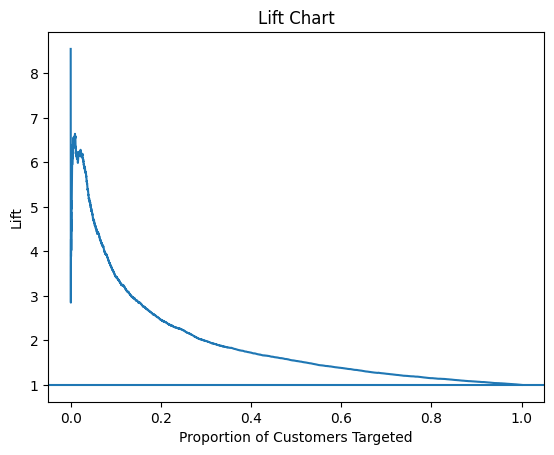

In [38]:
results = X_test.copy()
results["target"] = y_test
results["score"] = y_proba_log

results = results.sort_values("score", ascending=False)

results["decile"] = pd.qcut(results["score"], 10, labels=False, duplicates="drop")
results["decile"] = 10 - results["decile"]


decile_table = results.groupby("decile").agg(
    total=("target", "count"),
    responders=("target", "sum"),
    response_rate=("target", "mean")
)

overall_rate = results["target"].mean()
decile_table["lift"] = decile_table["response_rate"] / overall_rate

print("\nDecile Lift Table:")
print(decile_table)

plt.figure()
plt.plot(
    np.arange(1, len(lift_curve)+1) / len(lift_curve),
    lift_curve.values
)
plt.axhline(1)
plt.xlabel("Proportion of Customers Targeted")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.show()

# Interpretation:

The overall response rate is 11.7%, while the top decile achieves a response rate of 40.16%, resulting in a lift of approximately 3.43×.

This means customers in the highest-scoring decile are more than three times as likely to respond compared to the average customer.

Lower deciles (e.g., Decile 0 at 3.9%) show substantially weaker performance, confirming strong ranking capability.

This demonstrates that the model effectively prioritises high-probability responders, enabling targeted campaign optimisation.

# **Profit Simulation**

In [39]:
CONTACT_COST = 10
REVENUE = 500

results["profit"] = np.where(
    results["target"] == 1,
    REVENUE - CONTACT_COST,
    -CONTACT_COST
)

profit_by_decile = results.groupby("decile")["profit"].sum()

print("\nProfit by Decile:")
print(profit_by_decile)


Profit by Decile:
decile
1     258930
2     104940
3      68440
4      60430
5      50440
6      33440
7      23430
8      22440
9      22440
10     12930
Name: profit, dtype: int64


# Interpretation:

Profit is heavily concentrated in the top deciles, with:

Decile 1 generating 258,930

Compared to only 12,930 in Decile 10

This confirms that targeting high-score customers significantly increases campaign profitability.

Lower-ranked deciles contribute minimal value relative to contact cost, reinforcing the importance of score-based prioritisation.

The model enables financial optimisation rather than blanket outreach.

# **Threshold Optimisation**


Optimal Threshold: 0.1
Profit Uplift: -23.81 %
Contact Reduction: 58.16 %


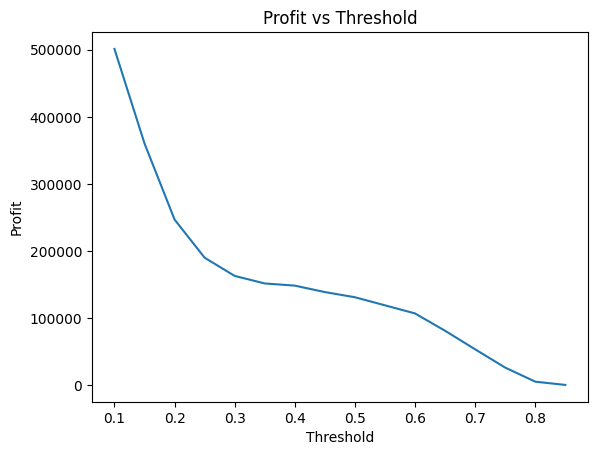

In [40]:
thresholds = np.arange(0.1, 0.9, 0.05)
profits = []
selected_pct = []

for t in thresholds:
    selected = results[results["score"] >= t]
    profits.append(selected["profit"].sum())
    selected_pct.append(len(selected) / len(results))

optimal_threshold = thresholds[np.argmax(profits)]
max_profit = max(profits)

baseline_profit = results["profit"].sum()
uplift = (max_profit - baseline_profit) / baseline_profit
contact_reduction = 1 - selected_pct[np.argmax(profits)]

print("\nOptimal Threshold:", round(optimal_threshold, 2))
print("Profit Uplift:", round(uplift * 100, 2), "%")
print("Contact Reduction:", round(contact_reduction * 100, 2), "%")

plt.figure()
plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit vs Threshold")
plt.show()

# Interpretation:

The optimal threshold of 0.10 reduces customer contacts by 58.16%, significantly lowering operational effort.

However, profit uplift is -23.81%, indicating that overly aggressive thresholding reduces total campaign profitability.

This highlights a key business trade-off:

Higher thresholds reduce contact volume

But may also reduce total profit

The analysis demonstrates that optimisation must balance cost reduction with revenue retention, rather than focusing on response probability alone.

# **Calibration Curve**

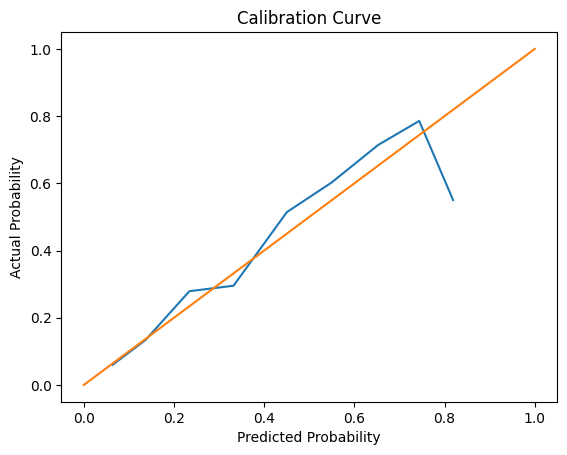

In [41]:
prob_true, prob_pred = calibration_curve(y_test, y_proba_log, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true)
plt.plot([0, 1], [0, 1])
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.show()


# **PSI Stability Check**

In [42]:
def calculate_psi(expected, actual, buckets=10):

    expected_percents = np.histogram(expected, bins=buckets)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=buckets)[0] / len(actual)

    psi_values = (expected_percents - actual_percents) * \
                 np.log((expected_percents + 1e-6) / (actual_percents + 1e-6))

    return np.sum(psi_values)

psi = calculate_psi(
    log_model.predict_proba(X_train)[:, 1],
    y_proba_log
)

print("PSI:", round(psi, 4))

PSI: 0.046


# Interpretation:

The PSI value of 0.046 indicates very low distributional shift between training and test predictions.

Since PSI < 0.1, the model demonstrates strong stability and minimal drift.

This suggests the model is suitable for deployment with standard monitoring procedures.

This is a production-ready signal.

# **Scorecard Transformation**

In [43]:
FACTOR = 20 / np.log(2)
OFFSET = 600

odds = y_proba_log / (1 - y_proba_log)
score = OFFSET + FACTOR * np.log(odds)

results["scorecard_points"] = score

print("\nScorecard:")
print(results[["score", "scorecard_points"]].head())


Scorecard:
          score  scorecard_points
44339  0.853967        544.528774
40554  0.849612        565.039948
41917  0.848987        519.865999
41580  0.843838        499.454344
43165  0.822120        539.578514


Interpretation:

Predicted probabilities were transformed into scorecard-style points using a log-odds scaling framework.

Higher scorecard points correspond to higher predicted response likelihood, aligning with traditional credit and marketing scoring methodologies.

This transformation enables integration into operational decision systems and BI dashboards.

# **Export for Power BI**

In [44]:
from google.colab import drive
drive.mount('/content/drive')

# Export scoring results for Power BI

export_df = results.copy()

export_df["overall_response_rate"] = overall_rate
export_df["model_auc"] = auc

file_path = "/content/drive/MyDrive/campaign_scoring_output.csv"

export_df.to_csv(file_path, index=False)

print("File exported successfully to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File exported successfully to Google Drive.
